In [2]:
# Preliminaries -----------------------------------------------------------
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, haven)

Loading required package: pacman



## Problem 1

Rows: 161060 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


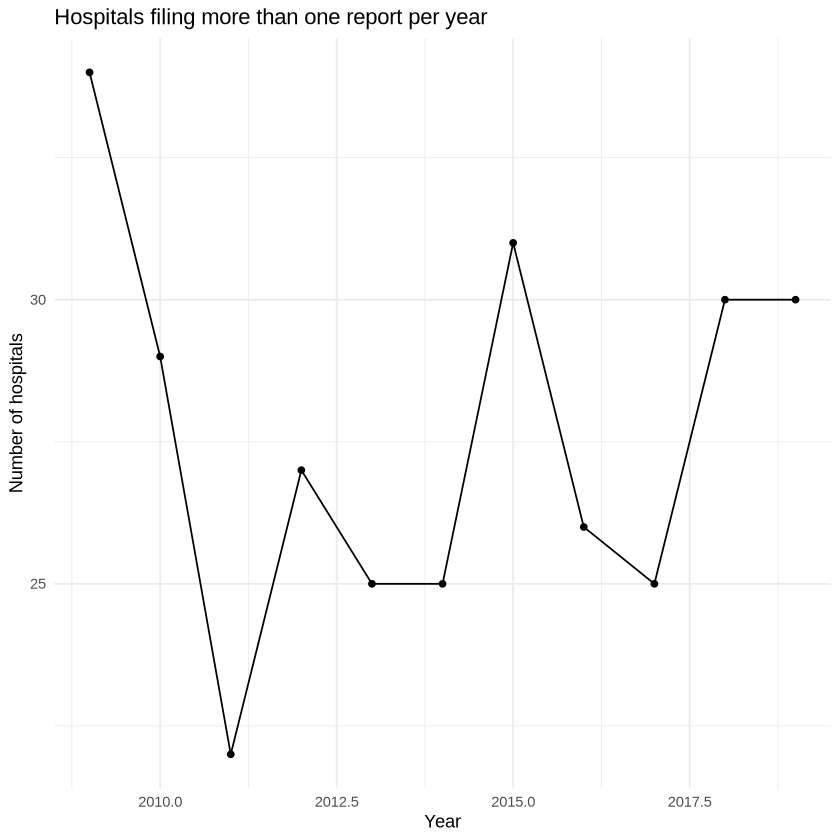

In [3]:
final.hcris <- read_tsv("../data/output/HCRIS_Data.txt")

dupes_by_year <- final.hcris %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  filter(source == "total for year") %>%
  group_by(year) %>%
  summarise(n_hospitals = n_distinct(provider_number))

ggplot(dupes_by_year, aes(x = year, y = n_hospitals)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Hospitals filing more than one report per year",
    x = "Year",
    y = "Number of hospitals"
  ) +
  theme_minimal()

## Problem 2

In [4]:
final.hcris %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  summarise(unique_hospitals = n_distinct(provider_number))

unique_hospitals
<int>
6897


## Problem 3

Warning message:
“Removed 2623 rows containing non-finite values (`stat_ydensity()`).”


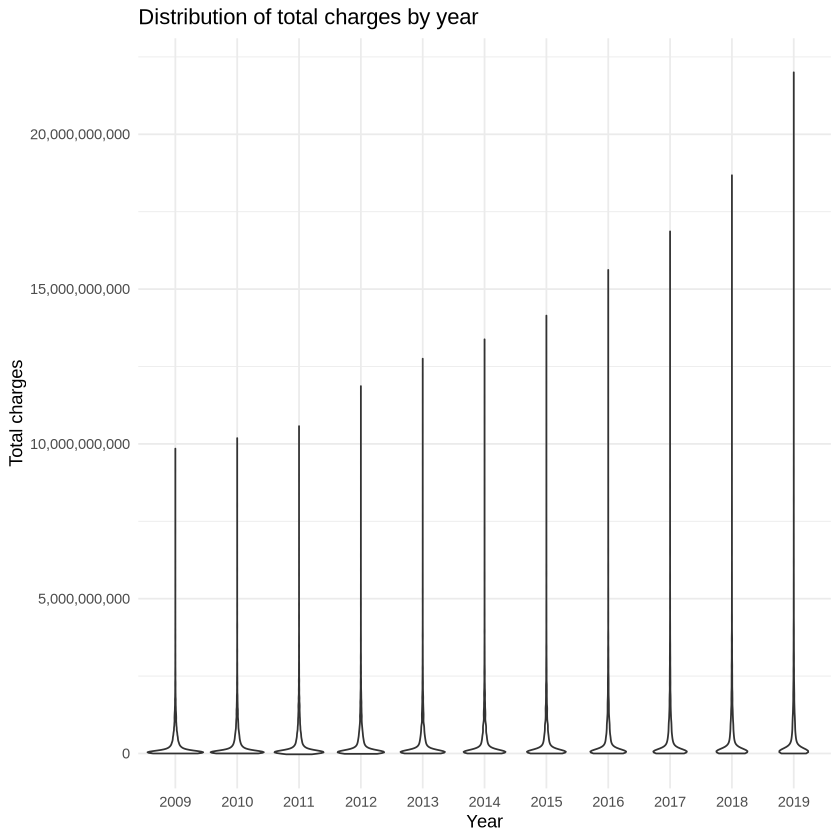

In [5]:
final.hcris %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  ggplot(aes(x = factor(year), y = tot_charges)) +
  geom_violin() +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Distribution of total charges by year",
    x = "Year",
    y = "Total charges"
  ) +
  theme_minimal()

## Problem 4

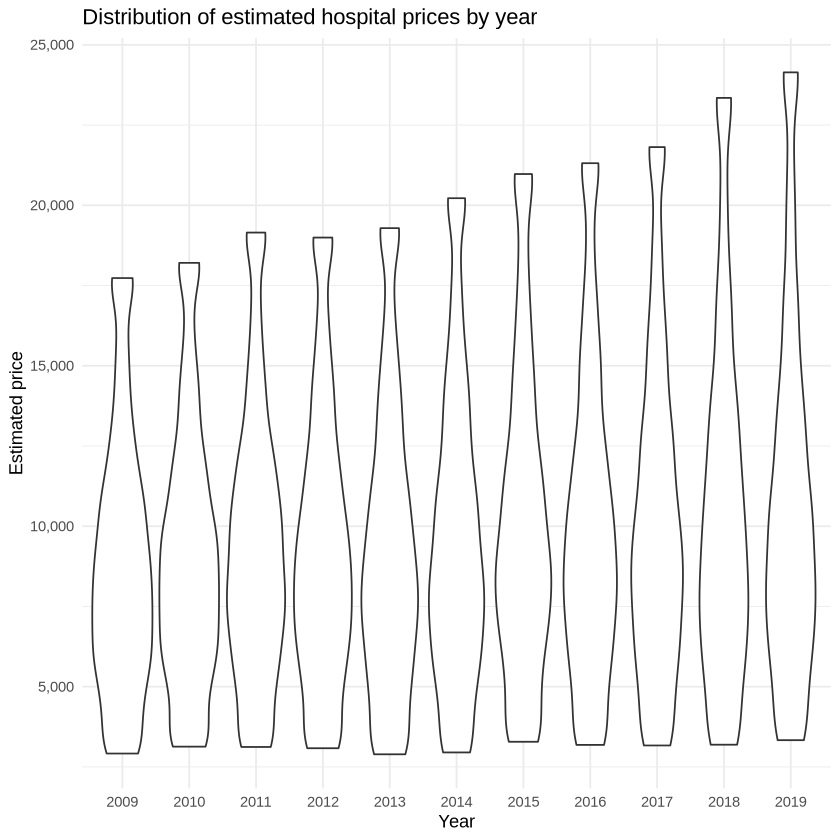

In [6]:
final.hcris %>%
  mutate(
    year = year(fy_end),
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(year >= 2009, year <= 2019) %>%
  filter(price > 0) %>%
  group_by(year) %>%
  mutate(
    p05 = quantile(price, 0.05, na.rm = TRUE),
    p95 = quantile(price, 0.95, na.rm = TRUE),
    price = pmin(pmax(price, p05), p95)
  ) %>%
  ggplot(aes(x = factor(year), y = price)) +
  geom_violin() +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Distribution of estimated hospital prices by year",
    x = "Year",
    y = "Estimated price"
  ) +
  theme_minimal()

## Problem 5

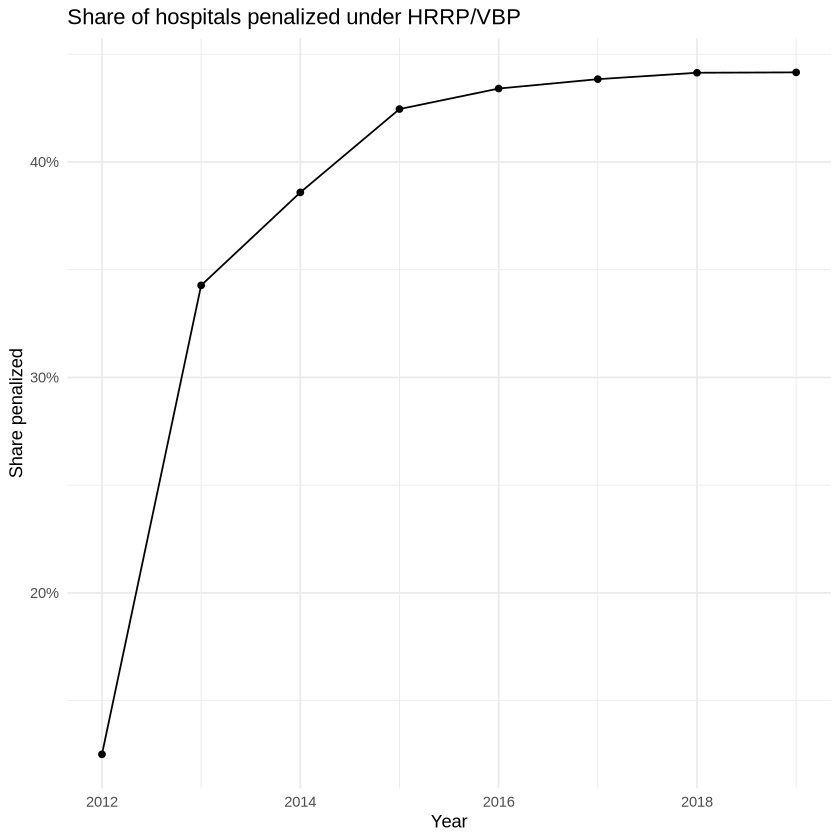

In [7]:
final.hcris %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2012, year <= 2019) %>%
  group_by(year) %>%
  summarise(
    total = n(),
    penalized = sum(hrrp_payment > 0, na.rm = TRUE),
    share_penalized = penalized / total
  ) %>%
  ggplot(aes(x = year, y = share_penalized)) +
  geom_line() +
  geom_point() +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Share of hospitals penalized under HRRP/VBP",
    x = "Year",
    y = "Share penalized"
  ) +
  theme_minimal()

## Problem 6

In [8]:
# Step 1: Calculate price for each hospital-year
hcris.price <- final.hcris %>%
  mutate(
    year = year(fy_end),
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(price > 0) %>%
  group_by(year) %>%
  mutate(
    p05 = quantile(price, 0.05, na.rm = TRUE),
    p95 = quantile(price, 0.95, na.rm = TRUE),
    price = pmin(pmax(price, p05), p95)
  ) %>%
  ungroup() %>%
  select(provider_number, year, price, beds, mcare_discharges, mcaid_discharges, hrrp_payment, hvbp_payment)

# Step 2: Price change from 2011 to 2014
price.change <- hcris.price %>%
  filter(year %in% c(2011, 2014)) %>%
  select(provider_number, year, price) %>%
  pivot_wider(names_from = year, values_from = price, names_prefix = "price_") %>%
  mutate(price_change = price_2014 - price_2011)

# Step 3: 2012 penalty (net = hrrp + hvbp)
penalty.2012 <- hcris.price %>%
  filter(year == 2012) %>%
  mutate(net_penalty = hrrp_payment + hvbp_payment) %>%
  select(provider_number, net_penalty)

# Step 4: Pre-2012 averages (2009-2011)
pre.2012 <- hcris.price %>%
  filter(year >= 2009, year <= 2011) %>%
  group_by(provider_number) %>%
  summarise(
    avg_beds = mean(beds, na.rm = TRUE),
    avg_mcare = mean(mcare_discharges, na.rm = TRUE),
    avg_mcaid = mean(mcaid_discharges, na.rm = TRUE)
  )

# Step 5: Combine into final dataset
hcris.final <- price.change %>%
  inner_join(penalty.2012, by = "provider_number") %>%
  inner_join(pre.2012, by = "provider_number") %>%
  filter(!is.na(price_change))

In [9]:
ols1 <- lm(price_change ~ net_penalty, data = hcris.final)
ols2 <- lm(price_change ~ net_penalty + avg_beds, data = hcris.final)
ols3 <- lm(price_change ~ net_penalty + avg_beds + avg_mcaid, data = hcris.final)

summary(ols1)
summary(ols2)
summary(ols3)


Call:
lm(formula = price_change ~ net_penalty, data = hcris.final)

Residuals:
     Min       1Q   Median       3Q      Max 
-11498.7  -1108.7     13.7   1083.2   8517.4 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.618e+02  9.463e+01   4.880 1.36e-06 ***
net_penalty -5.647e-05  1.327e-03  -0.043    0.966    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2073 on 599 degrees of freedom
  (1865 observations deleted due to missingness)
Multiple R-squared:  3.022e-06,	Adjusted R-squared:  -0.001666 
F-statistic: 0.00181 on 1 and 599 DF,  p-value: 0.9661



Call:
lm(formula = price_change ~ net_penalty + avg_beds, data = hcris.final)

Residuals:
     Min       1Q   Median       3Q      Max 
-11511.6  -1104.8     22.3   1080.0   8510.7 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.381e+02  9.474e+01   4.624 4.62e-06 ***
net_penalty -5.746e-05  1.322e-03  -0.043   0.9653    
avg_beds     6.623e-02  2.713e-02   2.442   0.0149 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2064 on 598 degrees of freedom
  (1865 observations deleted due to missingness)
Multiple R-squared:  0.009873,	Adjusted R-squared:  0.006562 
F-statistic: 2.982 on 2 and 598 DF,  p-value: 0.05147



Call:
lm(formula = price_change ~ net_penalty + avg_beds + avg_mcaid, 
    data = hcris.final)

Residuals:
     Min       1Q   Median       3Q      Max 
-11173.7  -1130.1     35.6   1056.9   7723.0 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.442e+02  1.104e+02   1.306   0.1919    
net_penalty -9.397e-04  1.309e-03  -0.718   0.4732    
avg_beds     6.214e-02  2.662e-02   2.334   0.0199 *  
avg_mcaid    2.108e-01  4.269e-02   4.937 1.03e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2025 on 597 degrees of freedom
  (1865 observations deleted due to missingness)
Multiple R-squared:  0.04871,	Adjusted R-squared:  0.04393 
F-statistic: 10.19 on 3 and 597 DF,  p-value: 1.493e-06


## Problem 7

Warning message:
“Removed 1865 rows containing missing values (`geom_point()`).”


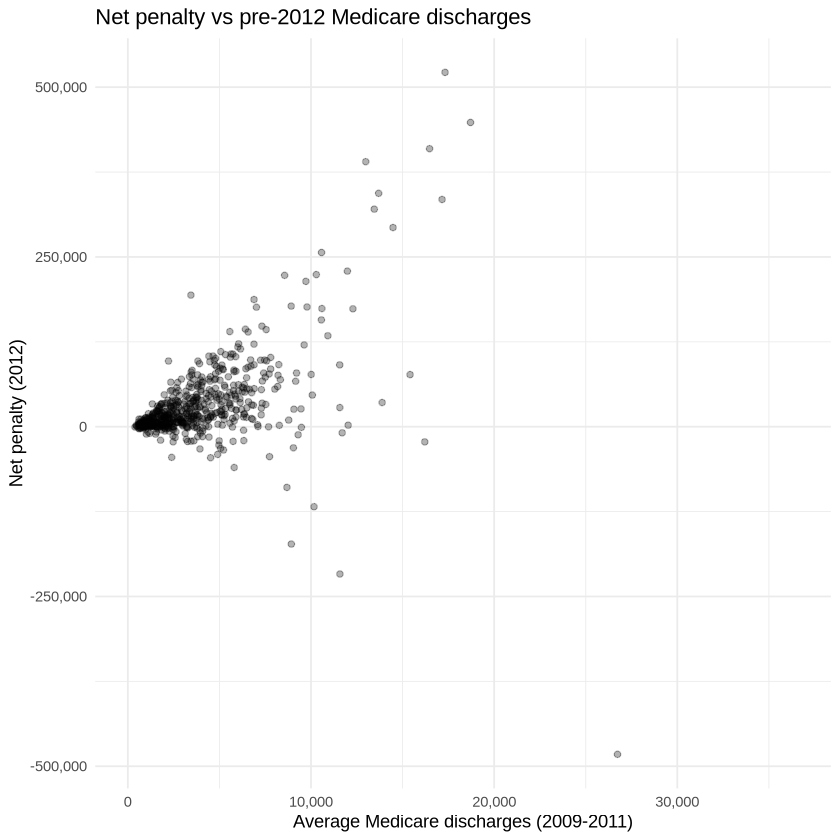

In [10]:
ggplot(hcris.final, aes(x = avg_mcare, y = net_penalty)) +
  geom_point(alpha = 0.3) +
  scale_x_continuous(labels = scales::comma) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Net penalty vs pre-2012 Medicare discharges",
    x = "Average Medicare discharges (2009-2011)",
    y = "Net penalty (2012)"
  ) +
  theme_minimal()

## Problem 8

In [11]:
library(fixest)

# First stage: net_penalty ~ avg_mcare (instrument)
fs1 <- feols(net_penalty ~ avg_mcare, data = hcris.final)
fs2 <- feols(net_penalty ~ avg_mcare + avg_beds, data = hcris.final)
fs3 <- feols(net_penalty ~ avg_mcare + avg_beds + avg_mcaid, data = hcris.final)

# Reduced form: price_change ~ avg_mcare (instrument)
rf1 <- feols(price_change ~ avg_mcare, data = hcris.final)
rf2 <- feols(price_change ~ avg_mcare + avg_beds, data = hcris.final)
rf3 <- feols(price_change ~ avg_mcare + avg_beds + avg_mcaid, data = hcris.final)

cat("=== First Stage ===\n")
summary(fs1)
summary(fs2)
summary(fs3)

cat("=== Reduced Form ===\n")
summary(rf1)
summary(rf2)
summary(rf3)

NOTE: 1,865 observations removed because of NA values (LHS: 1,865).

NOTE: 1,865 observations removed because of NA values (LHS: 1,865).

NOTE: 1,865 observations removed because of NA values (LHS: 1,865, RHS: 10).

NOTE: 10 observations removed because of NA values (RHS: 10).



=== First Stage ===


OLS estimation, Dep. Var.: net_penalty
Observations: 601 
Standard-errors: IID 
               Estimate  Std. Error   t value  Pr(>|t|)    
(Intercept) -3710.16037 3810.261987 -0.973728   0.33058    
avg_mcare       9.15915    0.770799 11.882672 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 57,300.6   Adj. R2: 0.189406

OLS estimation, Dep. Var.: net_penalty
Observations: 601 
Standard-errors: IID 
                Estimate  Std. Error   t value  Pr(>|t|)    
(Intercept) -3639.135250 3814.441396 -0.954041   0.34045    
avg_mcare       9.180594    0.772149 11.889672 < 2.2e-16 ***
avg_beds       -0.431020    0.755518 -0.570497   0.56856    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 57,285.0   Adj. R2: 0.188492

OLS estimation, Dep. Var.: net_penalty
Observations: 601 
Standard-errors: IID 
                Estimate  Std. Error   t value  Pr(>|t|)    
(Intercept) -2637.363617 3842.771879 -0.686318  0.492779    
avg_mcare       9.923996    0.864663 11.477294 < 2.2e-16 ***
avg_beds       -0.417023    0.753924 -0.553136  0.580377    
avg_mcaid      -2.544288    1.343078 -1.894370  0.058659 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 57,113.6   Adj. R2: 0.19199

=== Reduced Form ===


OLS estimation, Dep. Var.: price_change
Observations: 2,466 
Standard-errors: IID 
              Estimate Std. Error  t value Pr(>|t|)    
(Intercept) 195.664374   72.01124 2.717136 0.006631 ** 
avg_mcare     0.013011    0.01502 0.866280 0.386421    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,340.9   Adj. R2: -1.013e-4

OLS estimation, Dep. Var.: price_change
Observations: 2,466 
Standard-errors: IID 
              Estimate Std. Error  t value  Pr(>|t|)    
(Intercept) 190.995374  71.976917 2.653564 0.0080158 ** 
avg_mcare     0.009367   0.015090 0.620756 0.5348177    
avg_beds      0.070582   0.030637 2.303825 0.0213153 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,338.3   Adj. R2: 0.001644

OLS estimation, Dep. Var.: price_change
Observations: 2,456 
Standard-errors: IID 
              Estimate Std. Error  t value   Pr(>|t|)    
(Intercept) 146.393652  72.876276  2.00880 4.4668e-02 *  
avg_mcare    -0.023887   0.017318 -1.37928 1.6793e-01    
avg_beds      0.067236   0.030609  2.19657 2.8144e-02 *  
avg_mcaid     0.100757   0.025453  3.95859 7.7539e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,334.9   Adj. R2: 0.007593

## Problem 9

In [12]:
# IV estimates: price_change ~ net_penalty, instrumented by avg_mcare
iv1 <- feols(price_change ~ 1 | net_penalty ~ avg_mcare, data = hcris.final)
iv2 <- feols(price_change ~ avg_beds | net_penalty ~ avg_mcare, data = hcris.final)
iv3 <- feols(price_change ~ avg_beds + avg_mcaid | net_penalty ~ avg_mcare, data = hcris.final)

summary(iv1)
summary(iv2)
summary(iv3)

NOTE: 1,865 observations removed because of NA values (IV: 1,865/0).

NOTE: 1,865 observations removed because of NA values (IV: 1,865/0).

NOTE: 1,865 observations removed because of NA values (RHS: 10, IV: 1,865/0).



TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 601 
Standard-errors: IID 
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)     277.828146 130.902006 2.12241 0.034213 *  
fit_net_penalty   0.005692   0.003087 1.84396 0.065682 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,101.6   Adj. R2: -0.03302
F-test (1st stage), net_penalty: stat = 141.2    , p < 2.2e-16 , on 1 and 599 DoF.
                     Wu-Hausman: stat =   4.44506, p = 0.035418, on 1 and 598 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 601 
Standard-errors: IID 
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)     265.585964 130.424528 2.03632 0.042158 *  
fit_net_penalty   0.005332   0.003065 1.73957 0.082450 .  
avg_beds          0.066197   0.027501 2.40709 0.016382 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,087.6   Adj. R2: -0.021048
F-test (1st stage), net_penalty: stat = 141.4    , p < 2.2e-16, on 1 and 598 DoF.
                     Wu-Hausman: stat =   3.94812, p = 0.04738, on 1 and 597 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 601 
Standard-errors: IID 
                  Estimate Std. Error   t value   Pr(>|t|)    
(Intercept)     157.026391 130.847294  1.200074 2.3059e-01    
fit_net_penalty  -0.001449   0.003080 -0.470397 6.3824e-01    
avg_beds          0.062102   0.026628  2.332166 2.0024e-02 *  
avg_mcaid         0.213048   0.044467  4.791197 2.0944e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,018.7   Adj. R2: 0.043689
F-test (1st stage), net_penalty: stat = 131.7     , p < 2.2e-16 , on 1 and 597 DoF.
                     Wu-Hausman: stat =   0.033287, p = 0.855294, on 1 and 596 DoF.